In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numcosmo_sne.cosmology as cosmo
import numcosmo_sne.data as data
from pathlib import Path
figDir = Path("../outputs/figs/")

In [2]:
names, z, mu, mu_err, p_low, Wmat = data.readUnionData(Path("../data/union2.1"))
print(names)
_, _, _, _, _, _, _, _, Mu, _ = cosmo.FLRW(z, 0.3, 0.7, H0=70, omega_r=0)

['1993ah' '1993ag' '1993o' '1993b' '1992bs' '1992br' '1992bp' '1992bo'
 '1992bl' '1992bh' '1992bg' '1992bc' '1992aq' '1992ag' '1992ae' '1992p'
 '1990af' '1990o' '2001cz' '2001cn' '2001ba' '2000ca' '2000bh' '1999gp'
 '1993ac' '1994m' '1994s' '1994t' '1995ac' '1995ak' '1996ab' '1996bl'
 '1996bo' '1996bv' '1996c' '2000fa' '2000dk' '2000cn' '2000cf' '1999gd'
 '1999ek' '1999cc' '1998eg' '1998ef' '1998dx' '1998co' '1998ab' '1998v'
 '1997dg' '1997y' '1999aa' '1999ao' '1999ar' '1999aw' '1999bi' '1999bm'
 '1999bn' '1999bp' '2001ah' '2001ay' '2001az' '2001bf' '2001cp' '2001da'
 '2001eh' '2001g' '2001ie' '2001n' '2001v' '2002bf' '2002ck' '2002de'
 '2002do' '2002g' '2002hd' '2002he' '2002hu' '2002hw' '2002jy' '2002kf'
 '2003ch' '2003cq' '2003ic' '2003it' '2003iv' '2003kc' '2003u' '2003w'
 '2004as' '2004bg' '2004l' '2005eu' '2005hf' '2005hj' '2005ls' '2005lz'
 '2005mc' '2005ms' '2006ac' '2006al' '2006an' '2006ar' '2006az' '2006bq'
 '2006br' '2006bt' '2006bu' '2006bw' '2006cc' '2006cf' '2006cj' '200

In [3]:
residual = Mu - mu
chi2 = residual @ Wmat @ residual
lnLike = -0.5 * chi2

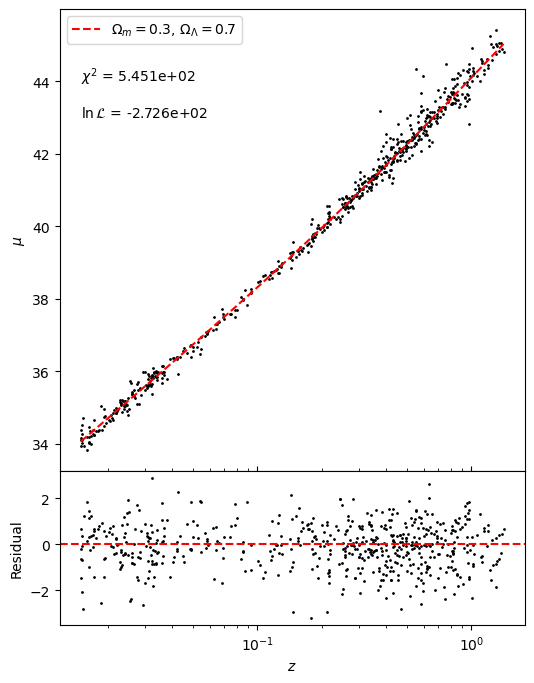

In [4]:
fig, ax = plt.subplots(nrows=2, sharex=True, gridspec_kw={'hspace': 0}, figsize=(6, 8), height_ratios=[3, 1])
order = np.argsort(z)
ax[0].scatter(z, mu, c="k", s=1)
ax[0].plot(z[order], Mu[order], ls="--", c="r", label=r"$\Omega_m=0.3$, $\Omega_\Lambda=0.7$")
ax[1].scatter(z, residual/mu_err, c="k", s=1)
ax[1].axhline(y=0, ls="--", c="r")
ax[0].set_xscale("log")
ax[1].set_xlabel(r"$z$")
ax[0].set_ylabel(r"$\mu$")
ax[1].set_ylabel("Residual")
ax[0].tick_params(axis='x', direction='in', which='both')
ax[0].text(0.015, 44, r"$\chi^2$ = "+f"{chi2:.3e}", c="k")
ax[0].text(0.015, 43, r"$\ln\mathcal{L}$ = "+f"{lnLike:.3e}", c="k")
ax[0].legend()
plt.savefig(figDir / "L-CDMdatafit.png", dpi=300)
plt.show()